# 01 — Raw Dataset Architecture Analysis

**Pipeline step:** Section 3.1 of the paper — initial exploration of the raw Telegram dataset
(Blas et al., 2025) before any filtering is applied.

**Purpose.** Sanity-check the raw dataset released by [Blas et al.](https://github.com/leonardo-blas/usc-tg-24-us-election)
before any processing: confirm how many public **channels** vs. **groups** ("chats") are present,
and how messages are distributed across months.

**Input:**
- `../data/telegram_2024/extracted/` — the raw dataset, extracted so that each chat has its own
  subfolder containing one `.tsv.gz` file per month (e.g. `<chat_id>/2024-03.tsv.gz`).

**Output:** this notebook is exploratory only — it does not write any files. It produces two
plots used to validate dataset coverage before moving on to `02_Save_data_month.ipynb`.

**Next step:** `02_Basic_Dataset_Exploration.ipynb`.


In [1]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt

In [ ]:
# Root folder of the extracted raw dataset. Each subfolder here corresponds to one
# Telegram chat (channel or group) and is expected to be named so that it contains the
# substring "channel" or "chat".
RAW_DATA_DIR = Path("../datatelegram_2024/extracted")

## Channels vs. groups

The dataset distinguishes between **channels** (one-to-many broadcast) and **groups**
(many-to-many discussion) — see paper Section 3.1. We classify each chat folder by its name
to check the overall proportion of each type before treating both uniformly as "chats".

In [3]:
chat_dirs = [p for p in RAW_DATA_DIR.iterdir() if p.is_dir()]

n_channels = sum(1 for p in chat_dirs if "channel" in p.name.lower())
n_groups = sum(1 for p in chat_dirs if "chat" in p.name.lower())
n_unclassified = len(chat_dirs) - n_channels - n_groups

print(f"Total chat folders found: {len(chat_dirs)}")
print(f"  Channels: {n_channels}")
print(f"  Groups:   {n_groups}")
if n_unclassified:
    print(f"  Unclassified (name matches neither pattern): {n_unclassified}")

Total chat folders found: 43826
  Channels: 43730
  Groups:   96


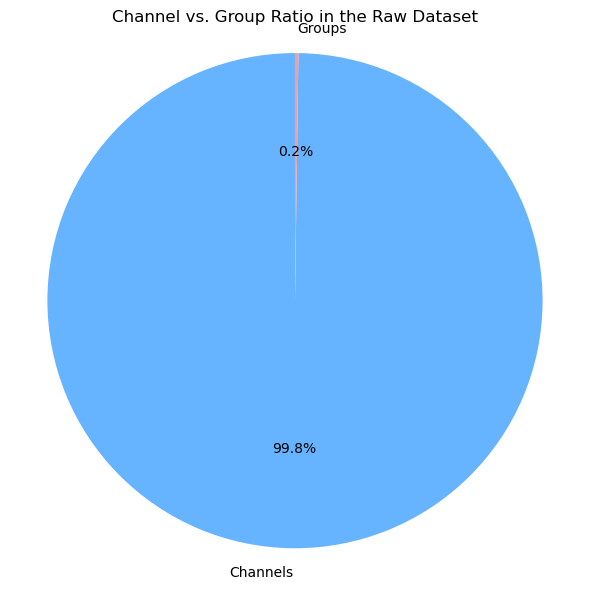

In [4]:
plt.figure(figsize=(6, 6))
plt.pie(
    [n_channels, n_groups],
    labels=["Channels", "Groups"],
    autopct="%1.1f%%",
    colors=["#66b3ff", "#ff9999"],
    startangle=90,
)
plt.title("Channel vs. Group Ratio in the Raw Dataset")
plt.axis("equal")
plt.tight_layout()
plt.show()

## Monthly coverage

Each chat folder contains one `.tsv.gz` file per month it was active
(e.g. `2024-03.tsv.gz`). We list which months are covered and how many chats have data
for each month, to confirm the dataset spans the expected period
(December 2023 – January 2025, per paper Section 3.1).

In [5]:
MONTH_FILE_RE = re.compile(r"(\d{4}-\d{2})\.tsv\.gz$")

monthly_files = list(RAW_DATA_DIR.glob("*/*.tsv.gz"))
months_present = sorted({
    m.group(1) for f in monthly_files if (m := MONTH_FILE_RE.search(f.name))
})

print(f"Total monthly files found: {len(monthly_files)}")
print(f"Months covered ({len(months_present)}): {months_present}")

Total monthly files found: 428205
Months covered (16): ['2019-08', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04', '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11', '2024-12', '2025-01']


In [6]:
files_per_month = Counter(
    m.group(1) for f in monthly_files if (m := MONTH_FILE_RE.search(f.name))
)

for month in months_present:
    print(f"{month}: {files_per_month[month]} chats with data")

2019-08: 1 chats with data
2023-11: 27603 chats with data
2023-12: 28640 chats with data
2024-01: 29588 chats with data
2024-02: 30112 chats with data
2024-03: 31074 chats with data
2024-04: 31807 chats with data
2024-05: 32683 chats with data
2024-06: 33319 chats with data
2024-07: 34106 chats with data
2024-08: 33852 chats with data
2024-09: 31742 chats with data
2024-10: 29589 chats with data
2024-11: 27787 chats with data
2024-12: 9741 chats with data
2025-01: 7004 chats with data


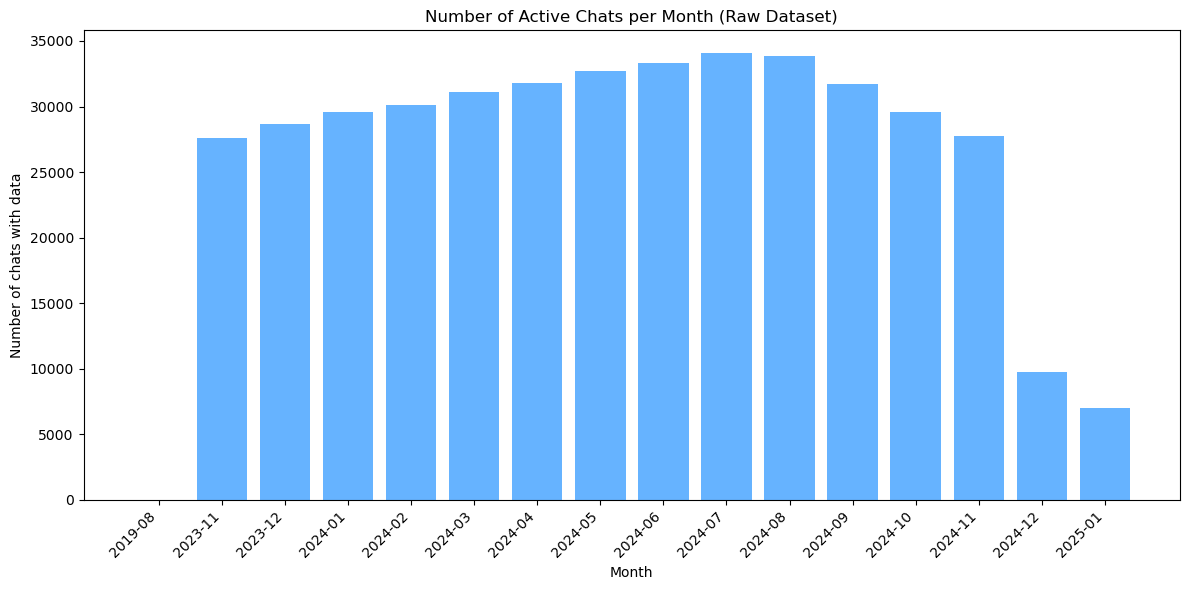

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(months_present, [files_per_month[m] for m in months_present], color="#66b3ff")
plt.title("Number of Active Chats per Month (Raw Dataset)")
plt.xlabel("Month")
plt.ylabel("Number of chats with data")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()